# Modelos Comerciales

In [48]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [49]:
import numpy as np

In [89]:
import pandas as pd
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
print(df.head())
df['discharge_armley_diff'] = df['discharge_armley'].diff(periods=180)
df = df.dropna(subset=['discharge_armley_diff'])

        Date  SF_absolute_humidity  SF_relative_humidity  \
0 2020-10-29                   8.6                  87.7   
1 2020-10-30                   9.7                  90.6   
2 2020-10-31                   8.7                  83.4   
3 2020-11-01                   8.9                  81.4   
4 2020-11-02                   8.1                  78.4   

   SF_mean_air_temperature  SF_atmospheric_pressure  SF_potential_evaporation  \
0                     10.5                    998.3                       0.6   
1                     12.0                   1004.6                       0.6   
2                     11.5                    998.2                       0.9   
3                     12.2                    987.4                       1.4   
4                     11.2                    990.2                       1.4   

   SF_net_radiation  SF_volumetric_water_content  SF_soil_temperature  \
0               0.1                         35.8                  9.6   
1     

In [90]:
import pandas as pd
from sklearn.model_selection import train_test_split


## Separación de training validación y test

In [91]:
# Supongamos que 'df' es tu DataFrame original con los datos ordenados temporalmente
train_size = int(len(df) * 0.7)  # Usar el 70% para entrenamiento
train_data = df.iloc[:train_size]  # Datos de entrenamiento: desde el inicio hasta el 70%
test_data = df.iloc[train_size:]   # Datos de prueba: del 70% en adelante

# Verificar las primeras filas de cada conjunto para asegurar que la división es correcta
print(train_data.head())
print(test_data.head())


          Date  SF_absolute_humidity  SF_relative_humidity  \
180 2021-04-27                   6.2                  76.9   
181 2021-04-28                   5.2                  69.8   

     SF_mean_air_temperature  SF_atmospheric_pressure  \
180                      7.7                   1003.5   
181                      6.8                   1004.4   

     SF_potential_evaporation  SF_net_radiation  SF_volumetric_water_content  \
180                       1.5               5.4                         22.7   
181                       1.8               5.3                         25.2   

     SF_soil_temperature  SF_wind_speed  ...  river_level_kildwick  \
180                  9.6            2.6  ...                 0.244   
181                  9.1            3.1  ...                 0.251   

     river_level_kirkstall  headingley_precipitation  malham_precipitation  \
180                  1.563                      13.0                   1.4   
181                  1.524       

Se realizá una serparación de los datos, donde el 70% se usan para train, el 30% se usan para test

## Pronosticos

### Suavización exponencial de primer orden SES

In [53]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Función mejorada para probar diferentes valores de alpha y calcular métricas adicionales
def firstsmoothstats(train_data, test_data):
    alphas = np.arange(0.1, 0.9, 0.1)
    step = len(test_data)
    best_mae = float("inf")
    best_alpha = None
    best_metrics = {}

    for alpha in alphas:
        if 'discharge_armley_diff' in train_data.columns:
            train_series = train_data['discharge_armley_diff']
        else:
            raise KeyError("La columna 'discharge_armley' no se encontró en train_data.")
        
        ses_model = SimpleExpSmoothing(train_series).fit(smoothing_level=alpha, optimized=False)
        
        y_pred = ses_model.fittedvalues[-step:]
        
      
        if 'discharge_armley_diff' in train_data.columns:
            y_true = train_series.tail(step)
            mae = mean_absolute_error(y_true, y_pred)
            mse = mean_squared_error(y_true, y_pred)
            rmse = np.sqrt(mse)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            r2 = r2_score(y_true, y_pred)
        else:
            raise KeyError("La columna 'discharge_armley' no se encontró en train_data.")
        
        # Guardar el mejor alpha basado en el MAE
        if mae < best_mae:
            best_alpha = alpha
            best_mae = mae
            best_metrics = {
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'MAPE': mape,
                'R²': r2
            }
    
    return best_alpha, best_mae, best_metrics


best_alpha, best_mae, best_metrics = firstsmoothstats(train_data, test_data)
print(f"Mejor alpha: {best_alpha}, MAE: {best_mae}")
print("Métricas adicionales:", best_metrics)


Mejor alpha: 0.8, MAE: 13.752425054829356
Métricas adicionales: {'MAE': np.float64(13.752425054829356), 'MSE': np.float64(504.0204327243518), 'RMSE': np.float64(22.45039938897194), 'MAPE': np.float64(57.90642073933496), 'R²': 0.6825070025943645}


c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: 

c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


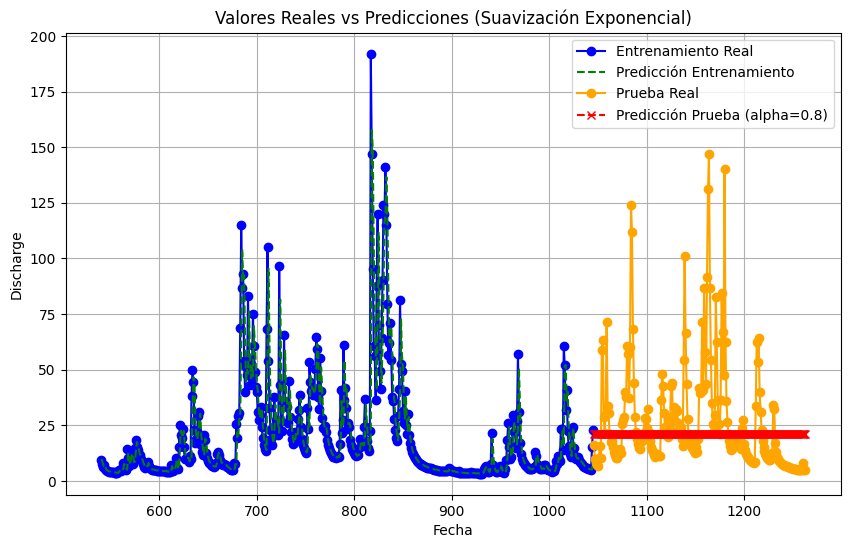

In [54]:
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

def plot_real_vs_pred_full(train_data, test_data, best_alpha):
    ses_model = SimpleExpSmoothing(train_data).fit(smoothing_level=best_alpha, optimized=False)
    
    y_pred_train = ses_model.fittedvalues  
    y_pred_test = ses_model.forecast(len(test_data))  
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(train_data.index, train_data, label='Entrenamiento Real', color='blue', marker='o', linestyle='-')
    plt.plot(train_data.index, y_pred_train, label='Predicción Entrenamiento', color='green', linestyle='--')
    
    plt.plot(test_data.index, test_data, label='Prueba Real', color='orange', marker='o', linestyle='-')
    plt.plot(test_data.index, y_pred_test, label=f'Predicción Prueba (alpha={best_alpha})', color='red', linestyle='--', marker='x')
   
    plt.xlabel('Fecha')
    plt.ylabel('Discharge')
    plt.title('Valores Reales vs Predicciones (Suavización Exponencial)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_real_vs_pred_full(train_data['discharge_armley'], test_data['discharge_armley'], best_alpha)


Se puede observar que la gráfica de las predicciones no se asemeja. Esto es porque la serie tiene componentes de tendencia, estacionalidad e irregularidades. Por lo tanto usar SES NO es la mejor opción ya que este modelo no tiene encuenta la tendencia ni la estacionalidad

c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


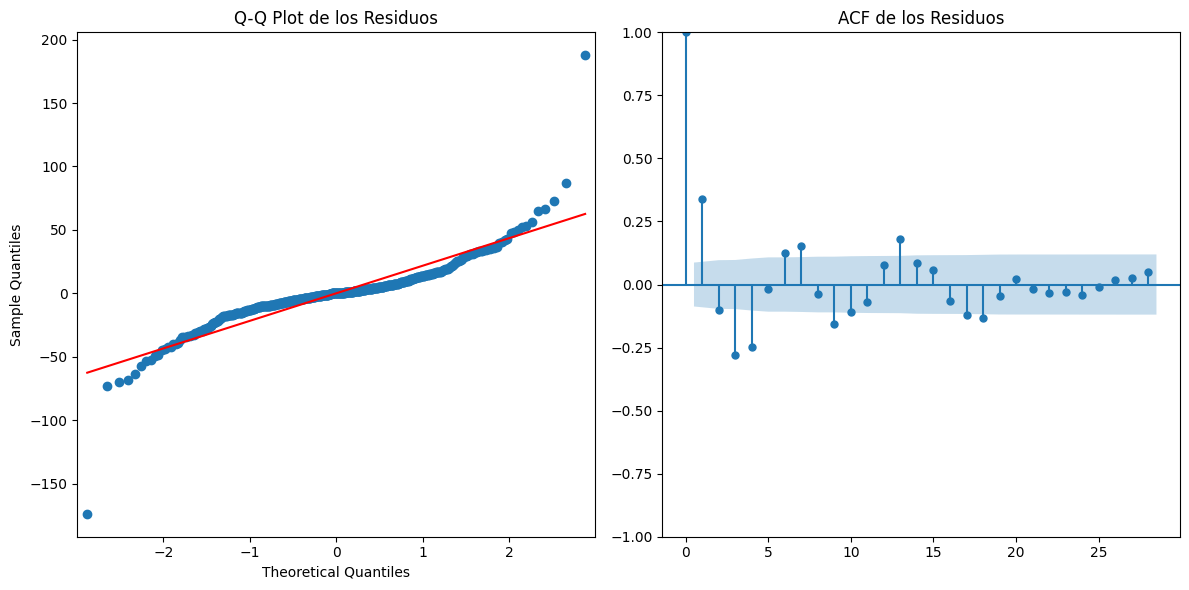

In [55]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import numpy as np

alpha = 0.5  # Usa el mejor valor de alpha obtenido previamente
train_series = train_data['discharge_armley_diff']

ses_model = SimpleExpSmoothing(train_series).fit(smoothing_level=alpha, optimized=False)

y_pred = ses_model.fittedvalues

best_residuals = train_series - y_pred  

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
qqplot(best_residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot de los Residuos')


plt.subplot(1, 2, 2)
plot_acf(best_residuals, ax=plt.gca())
plt.title('ACF de los Residuos')

plt.tight_layout()
plt.show()




En gráfico de Q-Q plot, la idea es que los puntos deberian alinearse a la diagonal roja si los residuos siguen una distribución normal. Es decir, los residuos no son completamente normales.

la ACF muestra que la correlación de los residuos en diferentes lags, además se observa que algunos lags tienen autocorrelación en los residuos


### Suavización exponencial de segundo orden

c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\isabe\AppData\Local\Temp\ipykernel_23092\1704953208.py:18: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  des_model = ExponentialSmoothing(train, trend='add').fit(smoothing_level=alpha, smoothing_slope=beta)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a m

Mejor alpha: 0.11, Mejor beta: 0.01, MAE: 27.687423414144696


c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\isabe\AppData\Local\Temp\ipykernel_23092\1704953208.py:18: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  des_model =

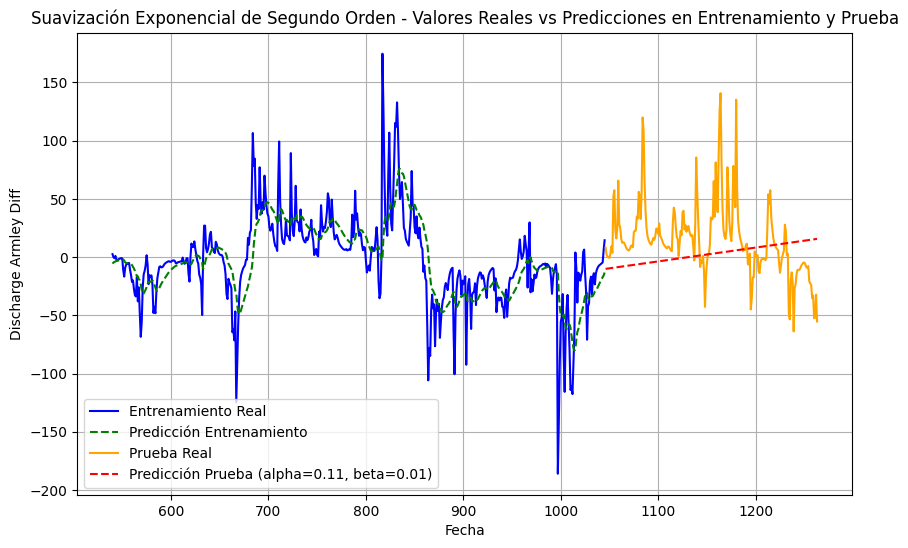

In [56]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

def secondsmoothstats(train, ts_test):
    alphas = np.arange(0.01, 1.0, 0.10)
    betas = np.arange(0.01, 1.0, 0.10)
    best_mae = float("inf")
    step = len(ts_test)
    mae_list = []

    best_alpha, best_beta, best_mae = None, None, best_mae
    
    for alpha in alphas:
        for beta in betas:
            
            des_model = ExponentialSmoothing(train, trend='add').fit(smoothing_level=alpha, smoothing_slope=beta)
            y_pred = des_model.forecast(step)
            
            mae = mean_absolute_error(ts_test, y_pred)
            mae_list.append(mae)
            
            if mae < best_mae:
                best_alpha, best_beta, best_mae = alpha, beta, mae

    return best_alpha, best_beta, best_mae, mae_list


def forecastsecondsmoothstats(train, ts_test, best_alpha, best_beta):
  
    des_model = ExponentialSmoothing(train, trend='add').fit(smoothing_level=best_alpha, smoothing_slope=best_beta)
    
    y_pred_train = des_model.fittedvalues
    
    step = len(ts_test)
    y_pred_test = des_model.forecast(step)
    
    return y_pred_train, y_pred_test

best_alpha, best_beta, best_mae, mae_list = secondsmoothstats(train_data['discharge_armley_diff'], test_data['discharge_armley_diff'])
y_pred_train, y_pred_test = forecastsecondsmoothstats(train_data['discharge_armley_diff'], test_data['discharge_armley_diff'], best_alpha, best_beta)


print(f"Mejor alpha: {best_alpha}, Mejor beta: {best_beta}, MAE: {best_mae}")

plt.figure(figsize=(10, 6))

plt.plot(train_data.index, train_data['discharge_armley_diff'], label='Entrenamiento Real', color='blue')
plt.plot(train_data.index, y_pred_train, label='Predicción Entrenamiento', color='green', linestyle='--')

plt.plot(test_data.index, test_data['discharge_armley_diff'], label='Prueba Real', color='orange')
plt.plot(test_data.index, y_pred_test, label=f'Predicción Prueba (alpha={best_alpha}, beta={best_beta})', color='red', linestyle='--')

plt.xlabel('Fecha')
plt.ylabel('Discharge Armley Diff')
plt.title('Suavización Exponencial de Segundo Orden - Valores Reales vs Predicciones en Entrenamiento y Prueba')
plt.legend()
plt.grid(True)
plt.show()


En color azul y verde muestra los datos de train junto a las predicciones, se observa que las lineas tienen un valor cercano. Los valores de suavización de alpha=0.81 y de beta=0.61 muestran una gran importancia a los datos recientes 

c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\isabe\AppData\Local\Temp\ipykernel_23092\3284101115.py:10: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  des_model = ExponentialSmoothing(train_series, trend='add').fit(smoothing_level=best_alpha, smoothing_slope=best_beta)


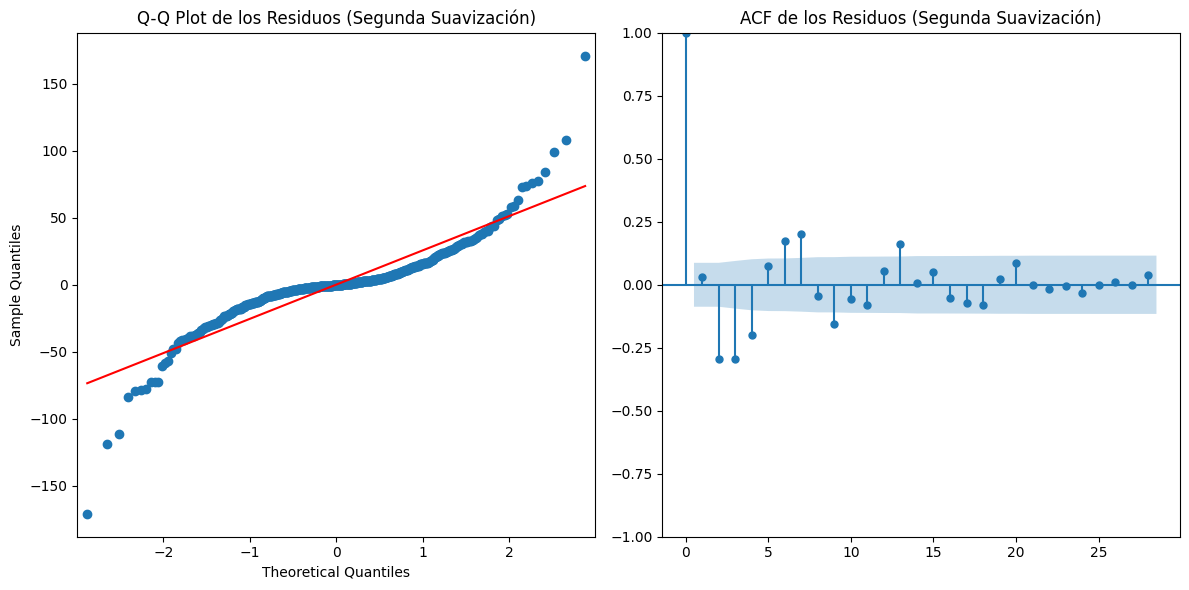

In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

best_alpha = 0.81  
best_beta = 0.61  

train_series = train_data['discharge_armley_diff']
des_model = ExponentialSmoothing(train_series, trend='add').fit(smoothing_level=best_alpha, smoothing_slope=best_beta)

y_pred_train = des_model.fittedvalues

best_residuals = train_series - y_pred_train

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
qqplot(best_residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot de los Residuos (Segunda Suavización)')

plt.subplot(1, 2, 2)
plot_acf(best_residuals, ax=plt.gca())
plt.title('ACF de los Residuos (Segunda Suavización)')

plt.tight_layout()
plt.show()


En el Q-Q plot se puede observar como se nistribuyen los residuos de acuerdo a la distribución normal y se puede osbervar que los residuos nos siguen una distribución normal, este se puede dar por los outliers.

En el ACF se observa que hay presencia de autocorrelación en los rezagos 3,4 y 10 y esto se puede dar debido a que en estos años los rediuos pueden estar relacionados en años anteriores

### ARIMA

Se implementa el modelo arima para hacer predicciones del caudal. Se optimizan los valores de (p,d,q) para optimizar los error MAE

Mejor combinación encontrada: p=0, d=0, q=0 con MAE=23.35160864351713
Mejor combinación encontrada: p=0, d=0, q=1 con MAE=23.165347046884627
Mejor combinación encontrada: p=0, d=0, q=2 con MAE=23.05491301855606
Mejor combinación encontrada: p=0, d=1, q=0 con MAE=7.592678571428571


c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters fou


Mejor combinación final: p=0, d=1, q=0 con MAE=7.592678571428571
MAE del modelo ARIMA en el conjunto de prueba: 7.592678571428571


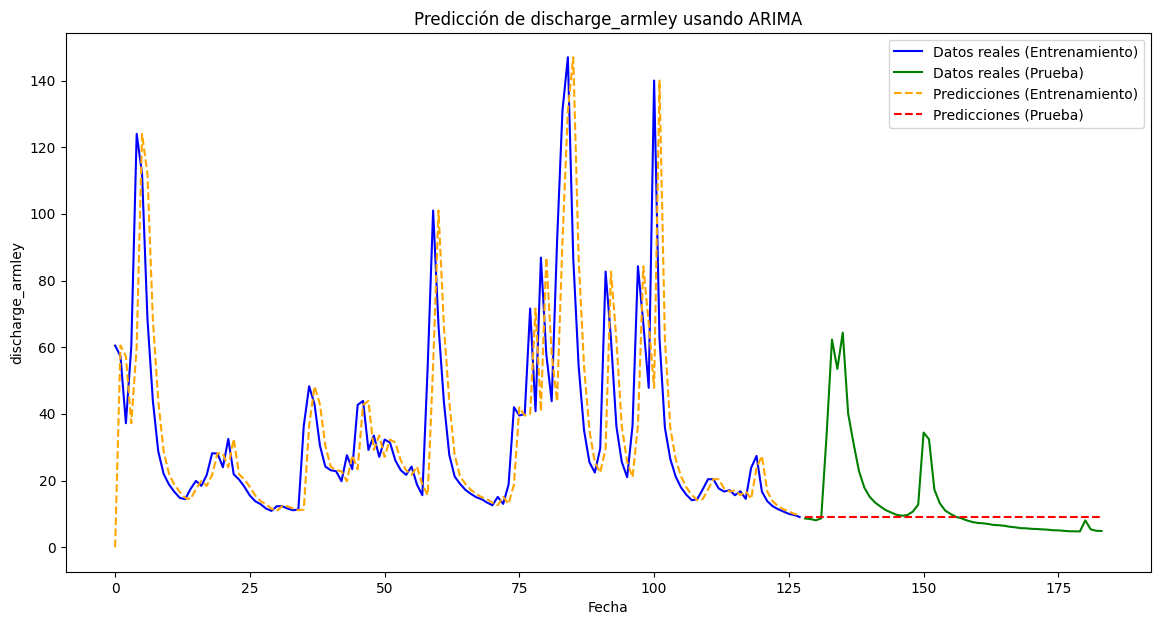

In [70]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import itertools

p = d = q = range(0, 3) 
pdq = list(itertools.product(p, d, q))

best_mae = float("inf")
best_params = None

for param in pdq:
    try:
        model = ARIMA(train_data, order=param).fit()
        
        predictions = model.forecast(steps=len(test_data))
        
        mae = mean_absolute_error(test_data, predictions)
        
        if mae < best_mae:
            best_mae = mae
            best_params = param
            print(f"Mejor combinación encontrada: p={param[0]}, d={param[1]}, q={param[2]} con MAE={mae}")
            
    except Exception as e:
        print(f"Error con parámetros {param}: {e}")
        continue

print(f"\nMejor combinación final: p={best_params[0]}, d={best_params[1]}, q={best_params[2]} con MAE={best_mae}")

model = ARIMA(train_data, order=best_params).fit()

predictions_train = model.predict(start=train_data.index[0], end=train_data.index[-1])

predictions_test = model.forecast(steps=len(test_data))

mae_test = mean_absolute_error(test_data, predictions_test)
print(f"MAE del modelo ARIMA en el conjunto de prueba: {mae_test}")

plt.figure(figsize=(14, 7))

plt.plot(train_data.index, train_data, label="Datos reales (Entrenamiento)", color="blue")
plt.plot(test_data.index, test_data, label="Datos reales (Prueba)", color="green")

plt.plot(train_data.index, predictions_train, label="Predicciones (Entrenamiento)", linestyle="--", color="orange")
plt.plot(test_data.index, predictions_test, label="Predicciones (Prueba)", linestyle="--", color="red")

plt.title("Predicción de discharge_armley usando ARIMA")
plt.xlabel("Fecha")
plt.ylabel("discharge_armley")
plt.legend()
plt.show()


Se observa gran cercania entre los datos de train y las predicciones, en cambio en el test se puede observa poca precisión de los pornosticos

<Figure size 1000x600 with 0 Axes>

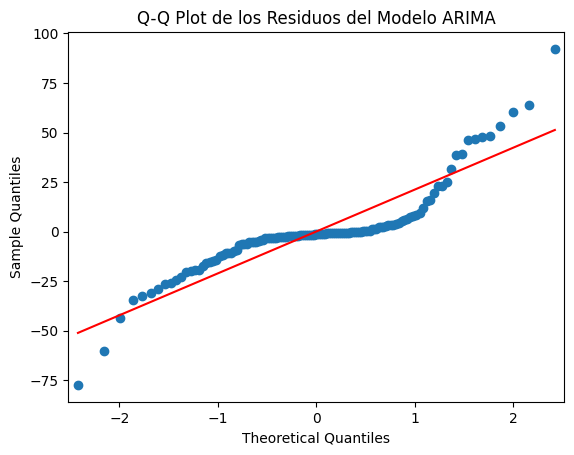

<Figure size 1000x600 with 0 Axes>

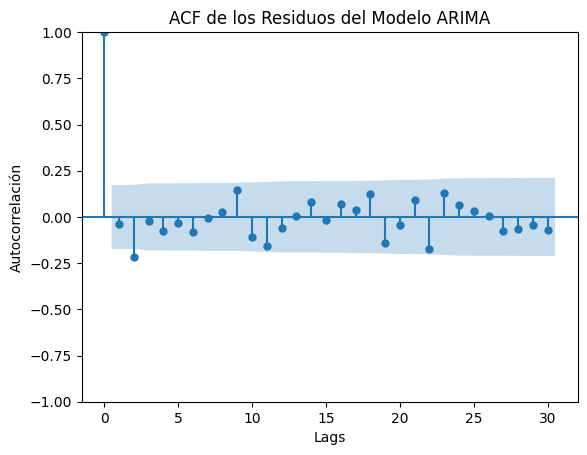

In [72]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

residuos = model.resid

plt.figure(figsize=(10, 6))
sm.qqplot(residuos, line='s')
plt.title("Q-Q Plot de los Residuos del Modelo ARIMA")
plt.show()

plt.figure(figsize=(10, 6))
sm.graphics.tsa.plot_acf(residuos, lags=30)
plt.title("ACF de los Residuos del Modelo ARIMA")
plt.xlabel("Lags")
plt.ylabel("Autocorrelación")
plt.show()


En el Q-Q plot se observan con los resiudos no siguen una distribución normal 

En el ACF se puede observar que los resuduos no tienen autocorrelación significativa, peero el 3 lag parece tener una pequeeña correlación

### SARIMA

c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA par

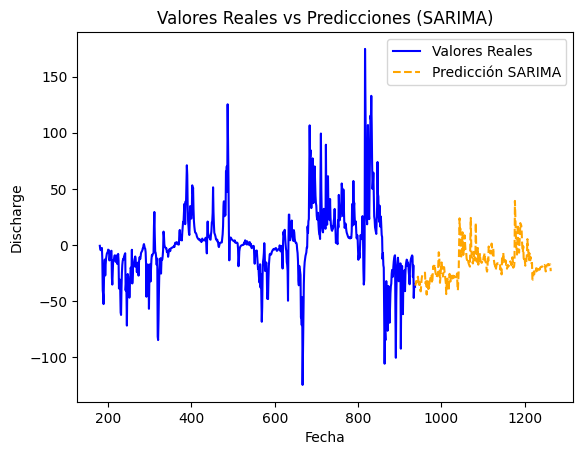

                                      SARIMAX Results                                      
Dep. Variable:               discharge_armley_diff   No. Observations:                  758
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 180)   Log Likelihood               -2560.535
Date:                             Sun, 27 Oct 2024   AIC                           5131.070
Time:                                     23:53:12   BIC                           5152.859
Sample:                                          0   HQIC                          5139.567
                                             - 758                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7915      0.033     23.875      0.000       0.727       0.856
ma.L1         -0.9635      

In [40]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt


sarima_model = SARIMAX(train_series, 
                       order=(1, 1, 1),       
                       seasonal_order=(1, 1, 1, 180)).fit()  # (P, D, Q, s)


sarima_pred = sarima_model.predict(start=len(train_series), 
                                   end=len(train_series) + len(test_data) - 1)


plt.plot(train_series.index, train_series, label="Valores Reales", color='blue')
plt.plot(test_data.index, sarima_pred, label="Predicción SARIMA", linestyle='--', color='orange')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Discharge")
plt.title("Valores Reales vs Predicciones (SARIMA)")
plt.show()

print(sarima_model.summary())



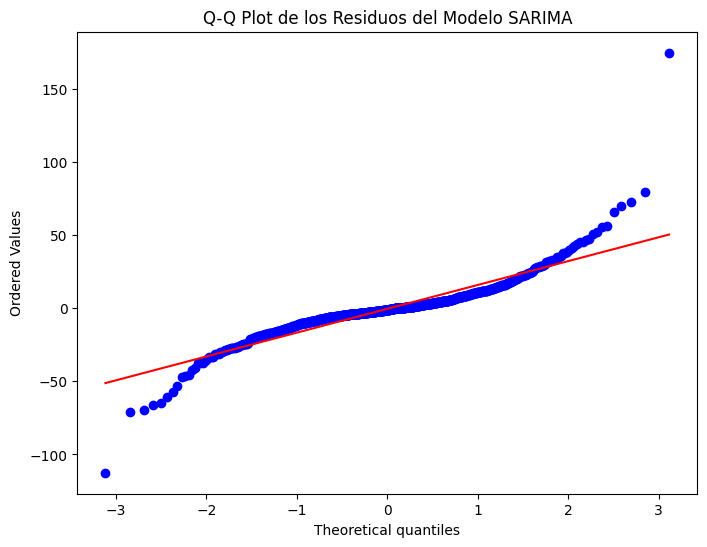

<Figure size 800x600 with 0 Axes>

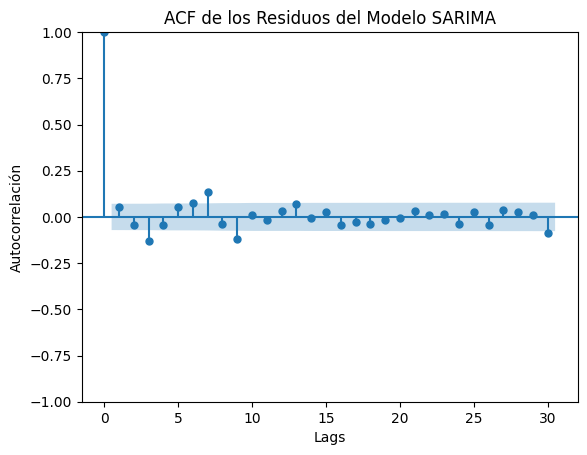

In [73]:
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
import matplotlib.pyplot as plt

# Calcula los residuos del modelo
residuos = sarima_model.resid

# Gráfico Q-Q Plot de los residuos
plt.figure(figsize=(8, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot de los Residuos del Modelo SARIMA")
plt.show()

# Gráfico de ACF de los residuos
plt.figure(figsize=(8, 6))
plot_acf(residuos, lags=30)
plt.title("ACF de los Residuos del Modelo SARIMA")
plt.xlabel("Lags")
plt.ylabel("Autocorrelación")
plt.show()


En el Q-Q plot se puede observar que los residuos no siguen la distribución normal y se puede observar una desviación en los extremos lo cual puede ser por presencia de valores atípicos.

ACF se observa que la mayoría de lag estan dentro d ela banda de significacia, es decir que no hay autocorrelación significativa en los residuos 

### Evaluación de modelos

In [92]:
print("Columnas en train_data:", train_data.columns)
print("Columnas en test_data:", test_data.columns)


Columnas en train_data: Index(['Date', 'SF_absolute_humidity', 'SF_relative_humidity',
       'SF_mean_air_temperature', 'SF_atmospheric_pressure',
       'SF_potential_evaporation', 'SF_net_radiation',
       'SF_volumetric_water_content', 'SF_soil_temperature', 'SF_wind_speed',
       'catchment_daily_precipitation_armley',
       'catchment_daily_precipitation_kildwick', 'discharge_armley',
       'discharge_kildwick', 'river_level_snaygill', 'river_level_kildwick',
       'river_level_kirkstall', 'headingley_precipitation',
       'malham_precipitation', 'skipton_snaygill_precipitation',
       'farnley_hall_precipitation', 'embsay_precipitation',
       'silsden_precipitation', 'lower_laithe_precipitation',
       'discharge_armley_diff'],
      dtype='object')
Columnas en test_data: Index(['Date', 'SF_absolute_humidity', 'SF_relative_humidity',
       'SF_mean_air_temperature', 'SF_atmospheric_pressure',
       'SF_potential_evaporation', 'SF_net_radiation',
       'SF_volumetric

In [97]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import itertools

metrics_df = pd.DataFrame(columns=["Modelo", "Alpha", "Beta", "p", "d", "q", "MAPE", "MAE", "RMSE", "MSE", "R²"])

def agregar_metricas(modelo, alpha=None, beta=None, p=None, d=None, q=None, y_true=None, y_pred=None):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    metrics_df.loc[len(metrics_df)] = {
        "Modelo": modelo,
        "Alpha": alpha if alpha is not None else "-",
        "Beta": beta if beta is not None else "-",
        "p": p if p is not None else "-",
        "d": d if d is not None else "-",
        "q": q if q is not None else "-",
        "MAPE": round(mape, 2) if not np.isinf(mape) else "inf",
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MSE": round(mse, 2),
        "R²": round(r2, 2)
    }

def firstsmoothstats(train_data, test_data):
    alphas = np.arange(0.1, 0.9, 0.1)
    step = len(test_data)
    
    for alpha in alphas:
        train_series = train_data['discharge_armley_diff']
        model = SimpleExpSmoothing(train_series).fit(smoothing_level=alpha, optimized=False)
        y_pred = model.forecast(step)
        
        agregar_metricas("SES Primer Orden", alpha=alpha, y_true=test_data['discharge_armley_diff'], y_pred=y_pred)

def secondsmoothstats(train, ts_test):
    alphas = np.arange(0.01, 1.0, 0.10)
    betas = np.arange(0.01, 1.0, 0.10)
    
    for alpha in alphas:
        for beta in betas:
            model = ExponentialSmoothing(train, trend='add').fit(smoothing_level=alpha, smoothing_slope=beta)
            y_pred = model.forecast(len(ts_test))
            agregar_metricas("SES Segundo Orden", alpha=alpha, beta=beta, y_true=ts_test, y_pred=y_pred)

def arima_model(train_data, test_data):
    p = d = q = range(0, 3)
    pdq = [(x[0], x[1], x[2]) for x in itertools.product(p, d, q)]
    
    for param in pdq:
        try:
            model = ARIMA(train_data['discharge_armley'], order=param).fit()
            y_pred = model.forecast(steps=len(test_data))
            agregar_metricas("ARIMA", p=param[0], d=param[1], q=param[2], y_true=test_data['discharge_armley'], y_pred=y_pred)
        except:
            continue

def sarima_model(train_data, test_data):
    train_series = train_data['discharge_armley']
    test_series = test_data['discharge_armley']
    
    model = SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 180)).fit()
    y_pred = model.predict(start=len(train_series), end=len(train_series) + len(test_series) - 1)
    
    agregar_metricas("SARIMA", p=1, d=1, q=1, y_true=test_series, y_pred=y_pred)

firstsmoothstats(train_data, test_data)
secondsmoothstats(train_data['discharge_armley_diff'], test_data['discharge_armley_diff'])
arima_model(train_data, test_data)
sarima_model(train_data, test_data)

styled_metrics_df = metrics_df.style.set_properties(**{
    'background-color': 'white',
    'border': '1px solid black',
    'color': 'black',
    'text-align': 'center'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', 'lightblue'), ('color', 'black'), ('font-weight', 'bold')]}
]).format(precision=2, na_rep="-")  # Precisión de dos decimales

styled_metrics_df


c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\isabe\miniconda3\envs\ven_st\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts canno

,Modelo,Alpha,Beta,p,d,q,MAPE,MAE,RMSE,MSE,R²
0,SES Primer Orden,0.10,-,-,-,-,-,11.48,14.39,207.09,-0.57
1,SES Primer Orden,0.20,-,-,-,-,-,11.48,14.36,206.16,-0.56
2,SES Primer Orden,0.30,-,-,-,-,-,11.48,14.33,205.23,-0.56
3,SES Primer Orden,0.40,-,-,-,-,-,11.48,14.29,204.31,-0.55
4,SES Primer Orden,0.50,-,-,-,-,-,11.48,14.26,203.39,-0.54
5,SES Primer Orden,0.60,-,-,-,-,-,11.48,14.23,202.48,-0.54
6,SES Primer Orden,0.70,-,-,-,-,-,11.48,14.20,201.58,-0.53
7,SES Primer Orden,0.80,-,-,-,-,-,11.48,14.17,200.68,-0.52
8,SES Segundo Orden,0.01,0.01,-,-,-,-,11.76,13.88,192.57,-0.46
9,SES Segundo Orden,0.01,0.11,-,-,-,-,11.76,13.88,192.57,-0.46
